In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/sample_submission.csv
/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/train.csv
/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/test.csv


In [2]:
train = pd.read_csv('/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/train.csv')
train.shape

(6818, 13)

Before doing any analysis, I wanted to understand the basic shape of the dataset: how many rows and columns it has, what the columns are called, and what a single row actually represents. The train set has 6,818 rows and 13 columns. Each row represents one product-store pairing, a specific product sold at a specific store, along with the total sales that combination generated. This matters because the task isn't "predict sales for a product" or "predict sales for a store" in isolation, it's predicting sales for a specific product-store combination, which is why both product-level and store-level columns appear together in every row.

In [3]:
train.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [4]:
train.isnull().sum()

id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

I checked every column for missing values rather than assuming the data was complete. Two columns had gaps: product_weight_kg (~18% missing) and store_size (~28% missing). Given how large these percentages are, I decided against simply dropping the affected rows; doing so could have removed up to 46% of the dataset in the worst case, discarding otherwise complete, useful information in every other column just because of one missing field. Instead, I planned to fill these gaps later (imputation) rather than delete data.

In [5]:
train.dtypes

id                      object
product_code            object
product_weight_kg      float64
fat_content             object
shelf_visibility       float64
product_category        object
product_price          float64
store_code              object
store_age_years          int64
store_size              object
store_location_tier     object
store_format            object
total_sales            float64
dtype: object

I checked each categorical column's actual values using .unique() rather than assuming their meaning from the column name alone. This distinguished two types of categorical data:

Ordinal (has a real order): store_size (Small/Medium/Large), store_location_tier (Tier_1/2/3), store_format (Corner Shop → Flagship Hypermarket, per the data dictionary's listed order), fat_content (Low Fat/Regular).
Nominal (no real order): product_category.

I also discovered that product_category had 47 unique values instead of the expected ~16, due to inconsistent capitalization (e.g. 'Canned', 'CANNED', 'canned' all appearing as separate categories). This is a real data quality issue (confirmed intentional by the dataset's own data dictionary) that would have distorted any category-level analysis if left unaddressed — for example, initial (uncleaned) groupby averages varied by 100+ units between different-cased versions of the same true category

In [6]:
train['store_format'].unique()

array(['Standard Supermarket', 'Flagship Hypermarket', 'Superstore',
       'Corner Shop'], dtype=object)

In [7]:
train['fat_content'].unique()

array(['Low Fat', 'Regular'], dtype=object)

In [8]:
train['store_location_tier'].unique()

array(['Tier_3', 'Tier_1', 'Tier_2'], dtype=object)

In [9]:
train['product_category'].unique()

array(['Frozen Foods', 'HEALTH AND HYGIENE', 'Canned', 'soft drinks',
       'meat', 'Snack Foods', 'baking goods', 'household', 'Household',
       'Dairy', 'dairy', 'CANNED', 'SNACK FOODS', 'HOUSEHOLD',
       'Soft Drinks', 'Fruits and Vegetables', 'Breakfast', 'Breads',
       'Meat', 'BAKING GOODS', 'canned', 'DAIRY', 'breakfast',
       'Baking Goods', 'Health and Hygiene', 'MEAT', 'Seafood',
       'fruits and vegetables', 'frozen foods', 'snack foods',
       'FROZEN FOODS', 'Others', 'FRUITS AND VEGETABLES',
       'health and hygiene', 'OTHERS', 'BREADS', 'SEAFOOD', 'SOFT DRINKS',
       'Hard Drinks', 'breads', 'starchy foods', 'hard drinks',
       'HARD DRINKS', 'others', 'Starchy Foods', 'seafood', 'BREAKFAST',
       'STARCHY FOODS'], dtype=object)

In [10]:
# Get summary statistics (count, mean, spread, min/max) for all numeric columns
train.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,5593.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.850876,0.065527,140.473623,34.178205,2174.756574
std,4.646542,0.051566,62.413513,8.384574,1697.894956
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.750000,0.026600,93.280000,28.000000,834.792500
50%,12.647000,0.053200,142.065000,33.000000,1790.890000
75%,16.894000,0.093400,185.987500,45.000000,3092.587500
max,21.883000,0.320100,273.040000,47.000000,12996.820000


I compared total_sales's mean (2174.76) to its median (1790.89) and found a meaningful gap, suggesting a right-skewed distribution; most product-store combinations generate modest sales, with a smaller number of high-sales outliers pulling the average upward. I confirmed this visually with a histogram, which showed a long tail extending toward the higher sales values. This is a normal, expected shape for real-world sales data, not a data error.

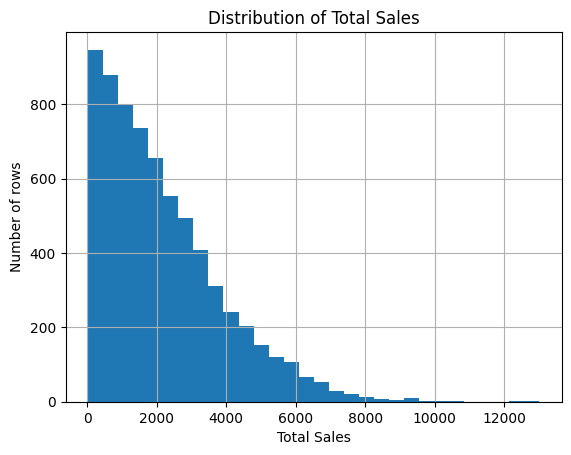

In [11]:
# Import matplotlib's plotting module, nicknamed plt by convention
import matplotlib.pyplot as plt

# Plot a histogram of total_sales, split into 30 bins
train['total_sales'].hist(bins=30)

# Label the chart so it's readable
plt.xlabel('Total Sales')
plt.ylabel('Number of rows')
plt.title('Distribution of Total Sales')
plt.show()

Rather than assuming which features would matter, I checked each one against total_sales directly:

Categorical columns (via group averages): store_format, store_size, store_location_tier, and product_category (after cleaning) all showed meaningful variation in average sales across their categories — suggesting real predictive value. Some patterns were counter-intuitive (e.g. Tier_1 — major urban centers — actually had the lowest average sales, not the highest), reinforcing the importance of checking real data rather than assuming.
Numeric columns (via correlation): product_price had the strongest relationship with total_sales (correlation ≈ 0.57), while product_weight_kg and store_age_years showed almost no linear relationship (≈0.02–0.04). A scatter plot of price vs. sales confirmed a real but noisy upward trend, not a perfect line — indicating price alone doesn't fully determine sales

In [12]:
# Group rows by store_format, then find the average total_sales within each group
train.groupby('store_format')['total_sales'].mean()

store_format
Corner Shop              336.353868
Flagship Hypermarket    3660.182219
Standard Supermarket    2316.319677
Superstore              1971.661954
Name: total_sales, dtype: float64

In [13]:
train.groupby('store_size')['total_sales'].mean()

store_size
Large     2254.890120
Medium    2670.506826
Small     1918.405954
Name: total_sales, dtype: float64

In [14]:
train.groupby('store_location_tier')['total_sales'].mean()

store_location_tier
Tier_1    1868.171278
Tier_2    2341.795296
Tier_3    2254.114400
Name: total_sales, dtype: float64

In [15]:
train.groupby('product_category')['total_sales'].mean()

product_category
BAKING GOODS             2051.639781
BREADS                   1853.545778
BREAKFAST                1996.679474
Baking Goods             1916.820039
Breads                   2292.078000
Breakfast                1827.852195
CANNED                   2231.389915
Canned                   2127.398229
DAIRY                    2124.938671
Dairy                    2226.652900
FROZEN FOODS             2086.570988
FRUITS AND VEGETABLES    2381.811379
Frozen Foods             2142.175491
Fruits and Vegetables    2193.589229
HARD DRINKS              2100.019167
HEALTH AND HYGIENE       2076.042525
HOUSEHOLD                2294.584270
Hard Drinks              2298.180978
Health and Hygiene       2023.714975
Household                2286.221344
MEAT                     2159.563298
Meat                     2372.897261
OTHERS                   2079.960000
Others                   1848.857671
SEAFOOD                  2212.578571
SNACK FOODS              2179.350131
SOFT DRINKS          

In [16]:
# Overwrite product_category with a lowercase version of itself, to fix the case-inconsistency mess
train['product_category'] = train['product_category'].str.lower()

In [17]:
train['product_category'].unique()

array(['frozen foods', 'health and hygiene', 'canned', 'soft drinks',
       'meat', 'snack foods', 'baking goods', 'household', 'dairy',
       'fruits and vegetables', 'breakfast', 'breads', 'seafood',
       'others', 'hard drinks', 'starchy foods'], dtype=object)

In [18]:
train.groupby('product_category')['total_sales'].mean()

product_category
baking goods             1943.416860
breads                   2186.152871
breakfast                1852.197765
canned                   2196.398743
dairy                    2238.317076
frozen foods             2140.770133
fruits and vegetables    2277.854672
hard drinks              2189.723195
health and hygiene       1996.266044
household                2292.464662
meat                     2264.310383
others                   1947.435833
seafood                  2262.524231
snack foods              2223.830568
soft drinks              1967.399454
starchy foods            2407.718584
Name: total_sales, dtype: float64

In [19]:
# Calculate correlation between total_sales and every other numeric column
train.corr(numeric_only=True)['total_sales']

product_weight_kg    0.015532
shelf_visibility    -0.118124
product_price        0.569833
store_age_years      0.039443
total_sales          1.000000
Name: total_sales, dtype: float64

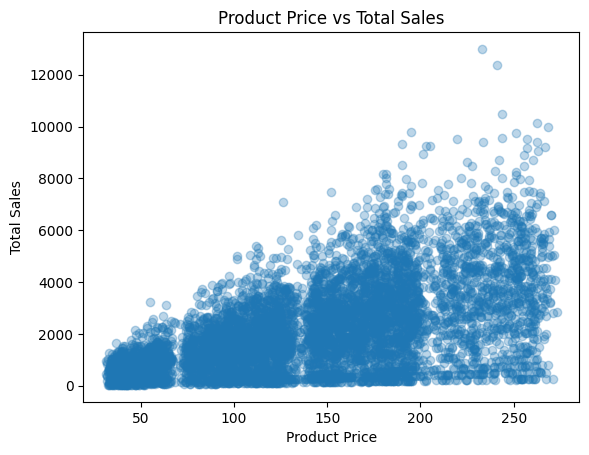

In [20]:
# Scatter plot: product_price on x-axis, total_sales on y-axis
plt.scatter(train['product_price'], train['total_sales'], alpha=0.3)

plt.xlabel('Product Price')
plt.ylabel('Total Sales')
plt.title('Product Price vs Total Sales')
plt.show()

* product_weight_kg (numeric, ~18% missing): checked whether the column was skewed by comparing mean (12.85) to median (12.65) — they were close, indicating a roughly symmetric distribution, so I used mean imputation.
* store_size (categorical, ~28% missing): filled missing values with the mode (most frequent category, "Medium"), since averaging text categories isn't meaningful.

Both train and test were filled using statistics calculated only from train, to avoid data leakage (letting information from the test set influence preprocessing decisions).

In [21]:
# Fill missing product_weight_kg values with the column's mean
train['product_weight_kg'] = train['product_weight_kg'].fillna(train['product_weight_kg'].mean())

In [22]:
train['product_weight_kg'].isnull().sum()

np.int64(0)

In [23]:
# Find which store_size category appears most often
train['store_size'].mode()

0    Medium
Name: store_size, dtype: object

In [24]:
# Fill missing store_size values with the most frequent category (Medium)
train['store_size'] = train['store_size'].fillna(train['store_size'].mode()[0])

In [25]:
train['store_size'].isnull().sum()

np.int64(0)

In [26]:
# Final check: confirm zero missing values across the entire dataset
train.isnull().sum()

id                     0
product_code           0
product_weight_kg      0
fat_content            0
shelf_visibility       0
product_category       0
product_price          0
store_code             0
store_age_years        0
store_size             0
store_location_tier    0
store_format           0
total_sales            0
dtype: int64

In [27]:
# Load the test dataset
test = pd.read_csv('/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/test.csv')

# Check its shape and columns
print(test.shape)
print(test.columns.tolist())

(1705, 12)
['id', 'product_code', 'product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category', 'product_price', 'store_code', 'store_age_years', 'store_size', 'store_location_tier', 'store_format']


In [28]:
# Standardize test's product_category casing, same as we did for train
test['product_category'] = test['product_category'].str.lower()

In [29]:
test['product_category'].unique()

array(['household', 'health and hygiene', 'fruits and vegetables',
       'frozen foods', 'seafood', 'baking goods', 'starchy foods',
       'snack foods', 'breads', 'soft drinks', 'canned', 'meat', 'dairy',
       'others', 'hard drinks', 'breakfast'], dtype=object)

In [30]:
# Check missing values in test
test.isnull().sum()

id                       0
product_code             0
product_weight_kg      306
fat_content              0
shelf_visibility         0
product_category         0
product_price            0
store_code               0
store_age_years          0
store_size             491
store_location_tier      0
store_format             0
dtype: int64

In [31]:
# Fill test's missing product_weight_kg using TRAIN's mean (not test's own mean)
test['product_weight_kg'] = test['product_weight_kg'].fillna(train['product_weight_kg'].mean())

In [32]:
# Fill test's missing store_size using TRAIN's mode (not test's own mode)
test['store_size'] = test['store_size'].fillna(train['store_size'].mode()[0])

In [33]:
test.isnull().sum()

id                     0
product_code           0
product_weight_kg      0
fat_content            0
shelf_visibility       0
product_category       0
product_price          0
store_code             0
store_age_years        0
store_size             0
store_location_tier    0
store_format           0
dtype: int64

In [34]:
# Manually define the order we want: Small=0, Medium=1, Large=2
size_order = {'Small': 0, 'Medium': 1, 'Large': 2}

# Map store_size text values to these numbers, in both train and test
train['store_size'] = train['store_size'].map(size_order)
test['store_size'] = test['store_size'].map(size_order)

In [35]:
train['store_size'].unique()

array([2, 0, 1])

In [36]:
train['store_size'].dtype

dtype('int64')

In [37]:
train['store_size'].unique()

array([2, 0, 1])

In [38]:
test['store_size'].unique()

array([1, 0, 2])

In [39]:
store_location_tier = {'Tier_1' : 2, 'Tier_2': 1, 'Tier_3': 0}

train['store_location_tier'] = train ['store_location_tier'].map(store_location_tier)
test['store_location_tier'] = test ['store_location_tier'].map(store_location_tier)

In [40]:
train['store_location_tier'].unique()

array([0, 2, 1])

In [41]:
train['store_location_tier'].dtype

dtype('int64')

In [42]:
train['store_location_tier'].unique()

array([0, 2, 1])

In [43]:
test['store_location_tier'].unique()

array([0, 1, 2])

In [44]:
# Define the order for store_format: Corner Shop (smallest) to Flagship Hypermarket (biggest)
store_format = {'Corner Shop': 0, 'Standard Supermarket': 1, 'Superstore': 2, 'Flagship Hypermarket': 3}

# Apply the mapping to both train and test
train['store_format'] = train['store_format'].map(store_format)
test['store_format'] = test['store_format'].map(store_format)

# Define the order for fat_content: Low Fat = 0, Regular = 1
fat_content = {'Low Fat': 0, 'Regular': 1}

# Apply the mapping to both train and test
train['fat_content'] = train['fat_content'].map(fat_content)
test['fat_content'] = test['fat_content'].map(fat_content)

In [45]:
train['store_format'].unique()
test['store_format'].unique()
train['fat_content'].unique()
test['fat_content'].unique()

array([0, 1])

In [46]:
train['store_format'].unique()

array([1, 3, 2, 0])

In [47]:
test['store_format'].unique()

array([2, 1, 3, 0])

In [48]:
train['fat_content'].unique()

array([0, 1])

In [49]:
test['fat_content'].unique()

array([0, 1])

In [50]:
train['store_size'].unique()

array([2, 0, 1])

In [51]:
train['store_location_tier'].unique()

array([0, 2, 1])

In [52]:
train['store_format'].unique()

array([1, 3, 2, 0])

In [53]:
train['fat_content'].unique()

array([0, 1])

In [54]:
test['store_size'].unique()

array([1, 0, 2])

In [55]:
test['store_location_tier'].unique()

array([0, 1, 2])

In [56]:
test['store_format'].unique()


array([2, 1, 3, 0])

In [57]:
test['fat_content'].unique()

array([0, 1])

Models require numeric input, so I converted each categorical column based on whether it had a natural order:

Ordinal encoding (manual integer mapping, preserving real-world order) for store_size, store_location_tier, store_format, and fat_content.
One-hot encoding (pd.get_dummies) for product_category (16 categories) and store_code (only 10 unique stores — low enough cardinality to be useful, unlike product_code).

I deliberately avoided one-hot encoding product_code (1,555 unique values) and id (unique per row), since both have very high cardinality — encoding them would create hundreds/thousands of mostly-empty columns carrying little to no generalizable signal, and id in particular is a pure identifier with zero real predictive meaning.

In [58]:
# One-hot encode product_category for train
train = pd.get_dummies(train, columns=['product_category'], prefix='cat')

# One-hot encode product_category for test
test = pd.get_dummies(test, columns=['product_category'], prefix='cat')

In [59]:
train.columns.tolist()

['id',
 'product_code',
 'product_weight_kg',
 'fat_content',
 'shelf_visibility',
 'product_price',
 'store_code',
 'store_age_years',
 'store_size',
 'store_location_tier',
 'store_format',
 'total_sales',
 'cat_baking goods',
 'cat_breads',
 'cat_breakfast',
 'cat_canned',
 'cat_dairy',
 'cat_frozen foods',
 'cat_fruits and vegetables',
 'cat_hard drinks',
 'cat_health and hygiene',
 'cat_household',
 'cat_meat',
 'cat_others',
 'cat_seafood',
 'cat_snack foods',
 'cat_soft drinks',
 'cat_starchy foods']

In [60]:
test.columns.tolist()

['id',
 'product_code',
 'product_weight_kg',
 'fat_content',
 'shelf_visibility',
 'product_price',
 'store_code',
 'store_age_years',
 'store_size',
 'store_location_tier',
 'store_format',
 'cat_baking goods',
 'cat_breads',
 'cat_breakfast',
 'cat_canned',
 'cat_dairy',
 'cat_frozen foods',
 'cat_fruits and vegetables',
 'cat_hard drinks',
 'cat_health and hygiene',
 'cat_household',
 'cat_meat',
 'cat_others',
 'cat_seafood',
 'cat_snack foods',
 'cat_soft drinks',
 'cat_starchy foods']

In [61]:
train.shape
test.shape

(1705, 27)

In [62]:
train.shape

(6818, 28)

In [63]:
train['product_code'].nunique()

1555

In [64]:
train['store_code'].nunique()

10

In [65]:
# One-hot encode store_code for train
train = pd.get_dummies(train, columns=['store_code'], prefix='store')

# One-hot encode store_code for test
test = pd.get_dummies(test, columns=['store_code'], prefix='store')

In [66]:
train.columns.tolist()

['id',
 'product_code',
 'product_weight_kg',
 'fat_content',
 'shelf_visibility',
 'product_price',
 'store_age_years',
 'store_size',
 'store_location_tier',
 'store_format',
 'total_sales',
 'cat_baking goods',
 'cat_breads',
 'cat_breakfast',
 'cat_canned',
 'cat_dairy',
 'cat_frozen foods',
 'cat_fruits and vegetables',
 'cat_hard drinks',
 'cat_health and hygiene',
 'cat_household',
 'cat_meat',
 'cat_others',
 'cat_seafood',
 'cat_snack foods',
 'cat_soft drinks',
 'cat_starchy foods',
 'store_STORE-7WS',
 'store_STORE-89Z',
 'store_STORE-9RG',
 'store_STORE-AGY',
 'store_STORE-DKU',
 'store_STORE-HL7',
 'store_STORE-JOR',
 'store_STORE-OYG',
 'store_STORE-T5G',
 'store_STORE-YLW']

In [67]:
test.columns.tolist()

['id',
 'product_code',
 'product_weight_kg',
 'fat_content',
 'shelf_visibility',
 'product_price',
 'store_age_years',
 'store_size',
 'store_location_tier',
 'store_format',
 'cat_baking goods',
 'cat_breads',
 'cat_breakfast',
 'cat_canned',
 'cat_dairy',
 'cat_frozen foods',
 'cat_fruits and vegetables',
 'cat_hard drinks',
 'cat_health and hygiene',
 'cat_household',
 'cat_meat',
 'cat_others',
 'cat_seafood',
 'cat_snack foods',
 'cat_soft drinks',
 'cat_starchy foods',
 'store_STORE-7WS',
 'store_STORE-89Z',
 'store_STORE-9RG',
 'store_STORE-AGY',
 'store_STORE-DKU',
 'store_STORE-HL7',
 'store_STORE-JOR',
 'store_STORE-OYG',
 'store_STORE-T5G',
 'store_STORE-YLW']

In [68]:
train.shape
test.shape

(1705, 36)

In [69]:
train.shape

(6818, 37)

In [70]:
# Save test's id column separately, for use in the final submission file later
test_ids = test['id']

# Drop id and product_code from train (id has no predictive value; product_code has high cardinality)
train = train.drop(columns=['id', 'product_code'])

# Drop the same columns from test, for consistency
test = test.drop(columns=['id', 'product_code'])

In [71]:
train.shape
test.shape
test_ids.head()

0    row_00009
1    row_00015
2    row_00019
3    row_00020
4    row_00023
Name: id, dtype: object

In [72]:
train.shape

(6818, 35)

In [73]:
test.shape

(1705, 34)

I split the training data 80/20 into a training set and a held-out validation set, to evaluate model performance on data the model never saw during training. This guards against overfitting — a model that performs well only on data it has memorized, rather than learning generalizable patterns. total_sales was separated out as the target (y), with all other columns as features (X), ensuring the target never leaked into the model's inputs.

In [74]:
# X = all our feature columns (everything except the target)
X = train.drop(columns=['total_sales'])

# y = just the target column, what we're trying to predict
y = train['total_sales']

In [75]:
X.head()
y.head()

0    1764.98
1     342.13
2     378.85
3    5595.72
4    2375.36
Name: total_sales, dtype: float64

In [76]:
# Import the splitting tool from scikit-learn
from sklearn.model_selection import train_test_split

# Split X and y into training (80%) and validation (20%) portions
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [77]:
X_train.shape
X_val.shape
y_train.shape
y_val.shape

(1364,)

In [78]:
X_train.shape

(5454, 34)

In [79]:
X_val.shape

(1364, 34)

In [80]:
y_train.shape

(5454,)

I compared three models on the same train/validation split, using RMSE and R² as evaluation metrics:

Model	Validation RMSE	R²
Linear Regression	1122.56	0.572
Random Forest (default)	1109.10	0.582

Random Forest outperformed Linear Regression on both metrics, likely because the price-vs-sales relationship (and others) isn't purely linear — Random Forest can capture more complex, non-linear patterns.

To confirm this wasn't due to a lucky single split, I ran 5-fold cross-validation on both models:

Linear Regression: 1129.73 average RMSE
Random Forest: 1117.26 average RMSE

Random Forest's advantage held up under cross-validation, confirming it as the stronger choice.

I later also tested XGBoost, a gradient boosting model that builds trees sequentially, each correcting the previous trees' errors. An untuned XGBoost initially scored worse than Random Forest (1127.09 vs 1109.10), but after tuning (see below), it became the best-performing model overall.

In [81]:
# Import the Linear Regression model from scikit-learn
from sklearn.linear_model import LinearRegression

# Create the model (untrained, just a blank formula-searcher for now)
model = LinearRegression()

# Train it: let it study X_train and y_train to find the best weights
model.fit(X_train, y_train)

LinearRegression()

In [82]:
# Use the trained model to predict total_sales for the validation set
y_pred = model.predict(X_val)

In [83]:
# Compare the first 5 predictions to the first 5 real answers
print(y_pred[:5])
print(y_val[:5].values)

[1379.4221998  1396.21427874 1970.01551402 1189.27922707  553.20076107]
[1549.79  751.34 1239.45  379.76  329.45]


In [84]:
# Import RMSE calculation tools from scikit-learn
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate RMSE: root mean squared error between predictions and actual values
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(rmse)

1122.5570366243871


In [85]:
from sklearn.metrics import r2_score

r2 = r2_score(y_val, y_pred)
print(r2)

0.5720053281237011


In [86]:
# Import Random Forest Regressor from scikit-learn
from sklearn.ensemble import RandomForestRegressor

# Create the model (100 trees is a common, reasonable default)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train it on the exact same training data as before
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [87]:
# Predict on validation set
rf_pred = rf_model.predict(X_val)

# Calculate RMSE and R²
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_pred))
rf_r2 = r2_score(y_val, rf_pred)

print(rf_rmse)
print(rf_r2)

1109.1022287385754
0.5822036077752581


In [88]:
# Import the cross-validation tool
from sklearn.model_selection import cross_val_score

# Run 5-fold cross-validation using our Random Forest model, scoring by RMSE
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='neg_root_mean_squared_error')

# Convert to positive RMSE values (sklearn returns them as negative by convention) and view all 5
print(-cv_scores)

# Average across all 5 folds
print((-cv_scores).mean())

[1064.95564767 1103.49919617 1133.34849514 1168.56830096 1115.92097662]
1117.2585233132627


In [89]:
# Import Linear Regression again (in case it's not already available in this session)
from sklearn.linear_model import LinearRegression

# Create a fresh Linear Regression model
lr_model = LinearRegression()

# Run 5-fold cross-validation on Linear Regression too
lr_cv_scores = cross_val_score(lr_model, X, y, cv=5, scoring='neg_root_mean_squared_error')

print(-lr_cv_scores)
print((-lr_cv_scores).mean())

[1077.94410395 1103.71343103 1135.1348023  1176.89261697 1154.95659971]
1129.7283107917904


I used GridSearchCV with 5-fold cross-validation to search over a small grid of hyperparameters for both Random Forest and XGBoost, rather than relying on default settings.

Random Forest: best combination was n_estimators=200, max_depth=10, min_samples_split=2, improving cross-validated RMSE from 1117.26 (default) to 1091.98.
XGBoost: best combination was n_estimators=100, max_depth=3, learning_rate=0.05, achieving a cross-validated RMSE of 1081.34 — the best result of any model tested.

This showed that comparing models fairly requires tuning each one properly first — an untuned XGBoost initially looked worse than Random Forest, but its true potential only emerged after tuning.

In [90]:
from sklearn.model_selection import GridSearchCV

# Define a small set of hyperparameter values to try
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Set up the grid search: try every combination, using 5-fold cross-validation, scoring by RMSE
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

# Run it (this will take a while — it's training many models: 2 x 3 x 2 = 12 combinations, each cross-validated 5 times = 60 total model trainings)
grid_search.fit(X, y)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error')

In [91]:
print(grid_search.best_params_)
print(-grid_search.best_score_)

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
1091.9811763873988


In [92]:
sample_sub = pd.read_csv('/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/sample_submission.csv')
sample_sub.head()

,id,total_sales
0,row_00009,2174.76
1,row_00015,2174.76
2,row_00019,2174.76
3,row_00020,2174.76
4,row_00023,2174.76


In [93]:
sample_sub.columns.tolist()

['id', 'total_sales']

In [94]:
# Train the final Random Forest using our best tuned settings, on ALL of train (not just X_train)
final_model = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=2, random_state=42)
final_model.fit(X, y)

# Predict total_sales for the real, unseen test set
test_predictions = final_model.predict(test)

In [95]:
# Build the submission DataFrame: id + predicted total_sales, matching sample_submission's format
submission = pd.DataFrame({
    'id': test_ids,
    'total_sales': test_predictions
})

# Save it as a CSV file, ready to upload to Kaggle
submission.to_csv('submission.csv', index=False)

# Quick peek to confirm it looks right
submission.head()

,id,total_sales
0,row_00009,2820.137666
1,row_00015,4545.705643
2,row_00019,3552.040622
3,row_00020,3007.145236
4,row_00023,2589.335376


In [96]:
import xgboost as xgb
print(xgb.__version__)

3.2.0


In [97]:
# Import the XGBoost regressor
from xgboost import XGBRegressor

# Create the model with reasonable starting settings
xgb_model = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)

# Train it on the same training split we've been using
xgb_model.fit(X_train, y_train)

# Predict on the validation set
xgb_pred = xgb_model.predict(X_val)

# Score it the same way as before
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_pred))
xgb_r2 = r2_score(y_val, xgb_pred)

print(xgb_rmse)
print(xgb_r2)

1127.0897731888977
0.568541978395132


In [98]:
# Define a small grid of XGBoost hyperparameters to try
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}

# Set up grid search: try every combination, 5-fold cross-validation, scored by RMSE
xgb_grid_search = GridSearchCV(
    XGBRegressor(random_state=42),
    xgb_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

# Run it — 2 x 3 x 2 = 12 combinations x 5 folds = 60 total trainings, similar scale to before
xgb_grid_search.fit(X, y)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error')

In [99]:
print(xgb_grid_search.best_params_)
print(-xgb_grid_search.best_score_)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
1081.3400221861734


In [100]:
# Train the final XGBoost model using the best settings GridSearchCV found, on ALL of train
final_xgb_model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42)
final_xgb_model.fit(X, y)

# Predict total_sales for the real, unseen test set
xgb_test_predictions = final_xgb_model.predict(test)

In [101]:
# Build the submission DataFrame with the new XGBoost predictions
xgb_submission = pd.DataFrame({
    'id': test_ids,
    'total_sales': xgb_test_predictions
})

# Save it as a new CSV file (different name so we don't overwrite the Random Forest one)
xgb_submission.to_csv('submission_xgb.csv', index=False)

# Quick peek to confirm it looks right
xgb_submission.head()

,id,total_sales
0,row_00009,2827.773438
1,row_00015,4139.337891
2,row_00019,3098.291016
3,row_00020,3158.447998
4,row_00023,2436.762695


In [102]:
import os
print(os.listdir('/kaggle/working'))

['submission_xgb.csv', 'submission.csv', '.virtual_documents']


In [103]:
from IPython.display import FileLink
FileLink('submission_xgb.csv')

/kaggle/working/submission_xgb.csv

In [104]:
import numpy as np

# Transform the target: train on log(total_sales) instead of raw total_sales
y_log = np.log1p(y)

# Split again, this time with the log-transformed target
X_train2, X_val2, y_train_log, y_val_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Train XGBoost on the log-transformed target, using our best tuned settings
log_model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42)
log_model.fit(X_train2, y_train_log)

# Predict (still in log-scale)
log_pred = log_model.predict(X_val2)

# Reverse the transformation to get real total_sales predictions back
real_pred = np.expm1(log_pred)

# To score fairly, compare against the REAL (non-log) validation answers
y_val_real = np.expm1(y_val_log)

log_rmse = np.sqrt(mean_squared_error(y_val_real, real_pred))
print(log_rmse)

1132.287995196775


In [105]:
# Create the new feature in both train and test
X['price_per_kg'] = X['product_price'] / X['product_weight_kg']
test['price_per_kg'] = test['product_price'] / test['product_weight_kg']

In [106]:
# Re-split since X now has an extra column
X_train3, X_val3, y_train3, y_val3 = train_test_split(X, y, test_size=0.2, random_state=42)

# Retrain XGBoost with the new feature included
feat_model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42)
feat_model.fit(X_train3, y_train3)

feat_pred = feat_model.predict(X_val3)
feat_rmse = np.sqrt(mean_squared_error(y_val3, feat_pred))
print(feat_rmse)

1075.7569829429017


In [107]:
# Cross-validate XGBoost with the new price_per_kg feature included
feat_cv_scores = cross_val_score(feat_model, X, y, cv=5, scoring='neg_root_mean_squared_error')
print(-feat_cv_scores)
print((-feat_cv_scores).mean())

[1027.05309691 1059.94750286 1089.15149097 1128.95200394 1101.5892943 ]
1081.3386777944886


In [108]:
# Get validation predictions from both tuned models
rf_val_pred = final_model.predict(X_val)
xgb_val_pred = final_xgb_model.predict(X_val)

# Average the two sets of predictions together
ensemble_val_pred = (rf_val_pred + xgb_val_pred) / 2

# Score the ensemble the same honest way as always
ensemble_rmse = np.sqrt(mean_squared_error(y_val, ensemble_val_pred))
print(ensemble_rmse)

977.2431045317845


In [109]:
X_val.shape
X.shape

(6818, 35)

In [110]:
X_val.shape

(1364, 34)

In [111]:
# Use models trained ONLY on X_train (not the full dataset) for a fair validation test
rf_train_pred = rf_model.predict(X_val)
xgb_train_pred = xgb_model.predict(X_val)

ensemble_fair_pred = (rf_train_pred + xgb_train_pred) / 2
ensemble_fair_rmse = np.sqrt(mean_squared_error(y_val, ensemble_fair_pred))
print(ensemble_fair_rmse)

1107.0338577520747


In [112]:
# Fresh tuned Random Forest, trained ONLY on X_train (not leaked)
rf_tuned_fair = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=2, random_state=42)
rf_tuned_fair.fit(X_train, y_train)

# Fresh tuned XGBoost, trained ONLY on X_train (not leaked)
xgb_tuned_fair = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42)
xgb_tuned_fair.fit(X_train, y_train)

# Predict on X_val with both, then average
rf_fair_pred = rf_tuned_fair.predict(X_val)
xgb_fair_pred = xgb_tuned_fair.predict(X_val)
ensemble_tuned_pred = (rf_fair_pred + xgb_fair_pred) / 2

ensemble_tuned_rmse = np.sqrt(mean_squared_error(y_val, ensemble_tuned_pred))
print(ensemble_tuned_rmse)

1079.9609555917546


In [113]:
from sklearn.model_selection import KFold

# Set up 5 folds, matching what we've used throughout
kf = KFold(n_splits=5, shuffle=True, random_state=42)

ensemble_scores = []

# Loop through each of the 5 folds
for train_idx, val_idx in kf.split(X):
    # Split X and y into this fold's train/validation portions
    X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
    y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Train fresh tuned models on this fold's training portion only
    rf_fold = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=2, random_state=42)
    rf_fold.fit(X_fold_train, y_fold_train)
    
    xgb_fold = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42)
    xgb_fold.fit(X_fold_train, y_fold_train)
    
    # Predict on this fold's validation portion, average the two models
    rf_fold_pred = rf_fold.predict(X_fold_val)
    xgb_fold_pred = xgb_fold.predict(X_fold_val)
    ensemble_fold_pred = (rf_fold_pred + xgb_fold_pred) / 2
    
    # Score this fold, store it
    fold_rmse = np.sqrt(mean_squared_error(y_fold_val, ensemble_fold_pred))
    ensemble_scores.append(fold_rmse)

print(ensemble_scores)
print(np.mean(ensemble_scores))

[np.float64(1080.6095115026942), np.float64(1058.7420573588076), np.float64(1096.4080731479924), np.float64(1119.9878200550813), np.float64(1071.8991657529775)]
1085.5293255635106


In [114]:
# Try a few different weight combinations for XGBoost vs Random Forest
for xgb_weight in [0.6, 0.7, 0.8]:
    rf_weight = 1 - xgb_weight
    scores = []
    
    for train_idx, val_idx in kf.split(X):
        X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
        y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]
        
        rf_fold = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=2, random_state=42)
        rf_fold.fit(X_fold_train, y_fold_train)
        
        xgb_fold = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42)
        xgb_fold.fit(X_fold_train, y_fold_train)
        
        rf_pred = rf_fold.predict(X_fold_val)
        xgb_pred = xgb_fold.predict(X_fold_val)
        
        # Weighted blend instead of simple average
        blend_pred = (xgb_weight * xgb_pred) + (rf_weight * rf_pred)
        
        fold_rmse = np.sqrt(mean_squared_error(y_fold_val, blend_pred))
        scores.append(fold_rmse)
    
    print(f"XGBoost weight {xgb_weight}: mean RMSE = {np.mean(scores)}")

XGBoost weight 0.6: mean RMSE = 1083.9874597406986
XGBoost weight 0.7: mean RMSE = 1082.7999544151903
XGBoost weight 0.8: mean RMSE = 1081.9680037802439


In [115]:
from sklearn.model_selection import RandomizedSearchCV

# A wider range of hyperparameters to sample from
xgb_param_dist = {
    'n_estimators': [50, 100, 150, 200, 300],
    'max_depth': [2, 3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# Randomly sample 30 combinations from this space, instead of trying all of them
xgb_random_search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    xgb_param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42
)

xgb_random_search.fit(X, y)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=30,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.07, 0.1],
                                        'max_depth': [2, 3, 4, 5, 6],
                                        'n_estimators': [50, 100, 150, 200,
                                                         300],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [116]:
print(xgb_random_search.best_params_)
print(-xgb_random_search.best_score_)

{'subsample': 0.9, 'n_estimators': 300, 'max_depth': 2, 'learning_rate': 0.03, 'colsample_bytree': 0.9}
1079.9756285955023


In [117]:
# Train the final model with the RandomizedSearchCV's best settings, on ALL of train
final_xgb_v2 = XGBRegressor(
    subsample=0.9, n_estimators=300, max_depth=2, learning_rate=0.03, colsample_bytree=0.9, random_state=42
)
final_xgb_v2.fit(X, y)

# Predict on test
xgb_v2_predictions = final_xgb_v2.predict(test)

# Build and save submission
xgb_v2_submission = pd.DataFrame({
    'id': test_ids,
    'total_sales': xgb_v2_predictions
})
xgb_v2_submission.to_csv('submission_xgb_v2.csv', index=False)
xgb_v2_submission.head()

,id,total_sales
0,row_00009,2843.759766
1,row_00015,4208.677246
2,row_00019,3063.613281
3,row_00020,3250.470947
4,row_00023,2520.560547


In [118]:
set(X.columns) == set(test.columns)

True

In [119]:
# Wider random search: try more combinations (60 instead of 30), same hyperparameter space
xgb_random_search2 = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    xgb_param_dist,
    n_iter=60,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42
)

xgb_random_search2.fit(X, y)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=60,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.07, 0.1],
                                        'max_depth': [2, 3, 4, 5, 6],
                                        'n_estimators': [50, 100, 150, 200,
                                                         300],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [120]:
print(xgb_random_search2.best_params_)
print(-xgb_random_search2.best_score_)

{'subsample': 0.7, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
1079.7162916664256


In [121]:
import lightgbm as lgb
print(lgb.__version__)

4.6.0


In [122]:
from lightgbm import LGBMRegressor

# Create the model with reasonable starting settings, matching XGBoost's scale for fair comparison
lgbm_model = LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)

# Cross-validate it the same honest way as every other model
lgbm_cv_scores = cross_val_score(lgbm_model, X, y, cv=5, scoring='neg_root_mean_squared_error')

print(-lgbm_cv_scores)
print((-lgbm_cv_scores).mean())

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002220 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1094
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 35
[LightGBM] [Info] Start training from score 2196.870514
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

In [123]:
from lightgbm import LGBMRegressor

# A wide hyperparameter space to sample from
lgbm_param_dist = {
    'n_estimators': [50, 100, 150, 200, 300],
    'max_depth': [3, 4, 5, 6, -1],  # -1 means "no limit" in LightGBM's convention
    'num_leaves': [15, 31, 50, 70],
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

lgbm_random_search = RandomizedSearchCV(
    LGBMRegressor(random_state=42, verbose=-1),
    lgbm_param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42
)

lgbm_random_search.fit(X, y)

RandomizedSearchCV(cv=5, estimator=LGBMRegressor(random_state=42, verbose=-1),
                   n_iter=30,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.07, 0.1],
                                        'max_depth': [3, 4, 5, 6, -1],
                                        'n_estimators': [50, 100, 150, 200,
                                                         300],
                                        'num_leaves': [15, 31, 50, 70],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [124]:
print(lgbm_random_search.best_params_)
print(-lgbm_random_search.best_score_)

{'subsample': 1.0, 'num_leaves': 50, 'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
1081.4034197691367


In [125]:
X.shape
test.shape

(1705, 35)

In [126]:
inter_cols = [col for col in X.columns if col.startswith('inter_')]
print(len(inter_cols))

0


In [127]:
X.shape
test.shape

(1705, 35)

In [128]:
X.shape

(6818, 35)

In [129]:
# Even wider search: 80 iterations this time, slightly expanded ranges
xgb_param_dist2 = {
    'n_estimators': [50, 100, 150, 200, 300, 400],
    'max_depth': [2, 3, 4, 5, 6],
    'learning_rate': [0.01, 0.02, 0.03, 0.05, 0.07, 0.1],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
}

xgb_random_search3 = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    xgb_param_dist2,
    n_iter=80,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42
)

xgb_random_search3.fit(X, y)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=80,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.02, 0.03,
                                                          0.05, 0.07, 0.1],
                                        'max_depth': [2, 3, 4, 5, 6],
                                        'n_estimators': [50, 100, 150, 200, 300,
                                                         400],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [130]:
print(xgb_random_search3.best_params_)
print(-xgb_random_search3.best_score_)

{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
1079.7540728565077


After settling on the tuned XGBoost model, I checked which features it actually relied on most, using its built-in `feature_importances_', a measure of how much each feature contributed to reducing error across all the model's trees. This was done to look for genuine, evidence-based directions for further feature engineering, rather than guessing blindly.

In [131]:
importances = final_xgb_v2.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feature_importance_df.head(15))

                      feature  importance
24            store_STORE-7WS    0.251063
7                store_format    0.221629
3               product_price    0.194216
34               price_per_kg    0.120127
4             store_age_years    0.031048
29            store_STORE-HL7    0.022696
22            cat_soft drinks    0.015053
6         store_location_tier    0.014515
33            store_STORE-YLW    0.011895
30            store_STORE-JOR    0.011866
14  cat_fruits and vegetables    0.010889
32            store_STORE-T5G    0.010594
17              cat_household    0.009513
23          cat_starchy foods    0.008828
26            store_STORE-9RG    0.007933


Reload the original store_code values temporarily, since we one-hot encoded them earlier
We can get this back from train's original store_code column before we transformed it, but since we've already transformed train, instead I'll check directly on the one-hot column itself

In [132]:
# Average total_sales for rows where store_STORE-7WS = 1, vs everywhere else
store_7ws_sales = train.loc[train['store_STORE-7WS'] == 1, 'total_sales'].mean()
other_stores_sales = train.loc[train['store_STORE-7WS'] == 0, 'total_sales'].mean()

print(f"STORE-7WS average sales: {store_7ws_sales}")
print(f"All other stores average sales: {other_stores_sales}")

STORE-7WS average sales: 3660.182219251337
All other stores average sales: 1991.7090642504118


In [133]:
train.loc[train['store_STORE-7WS'] == 1, 'store_format'].unique()

array([3])

In [134]:
import catboost
print(catboost.__version__)

1.2.10


In [135]:
from catboost import CatBoostRegressor

# Create the model with reasonable starting settings, silent output to avoid clutter
catboost_model = CatBoostRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, verbose=0)

# Cross-validate the same honest way as every other model
catboost_cv_scores = cross_val_score(catboost_model, X, y, cv=5, scoring='neg_root_mean_squared_error')

print(-catboost_cv_scores)
print((-catboost_cv_scores).mean())

[1026.1054763  1057.90058964 1081.3413121  1129.87779941 1101.7058393 ]
1079.386203347941


In [136]:
# CatBoost-specific hyperparameter space
catboost_param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1],
    'l2_leaf_reg': [1, 3, 5, 7, 9]
}

catboost_random_search = RandomizedSearchCV(
    CatBoostRegressor(random_state=42, verbose=0),
    catboost_param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42
)

catboost_random_search.fit(X, y)

RandomizedSearchCV(cv=5,
                   estimator=CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0),
                   n_iter=30,
                   param_distributions={'l2_leaf_reg': [1, 3, 5, 7, 9],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.07, 0.1],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'n_estimators': [100, 200, 300, 400]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [137]:
print(catboost_random_search.best_params_)
print(-catboost_random_search.best_score_)

{'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.07, 'l2_leaf_reg': 1}
1077.0548612406046


In [138]:
# Train final CatBoost model with best settings, on ALL of train
final_catboost = CatBoostRegressor(
    n_estimators=100, max_depth=5, learning_rate=0.07, l2_leaf_reg=1, random_state=42, verbose=0
)
final_catboost.fit(X, y)

# Predict on test
catboost_predictions = final_catboost.predict(test)

# Build and save submission
catboost_submission = pd.DataFrame({
    'id': test_ids,
    'total_sales': catboost_predictions
})
catboost_submission.to_csv('submission_catboost.csv', index=False)
catboost_submission.head()

,id,total_sales
0,row_00009,2899.939567
1,row_00015,4318.359721
2,row_00019,3033.062772
3,row_00020,3221.457557
4,row_00023,2446.228992


In [139]:
import os
print(os.listdir('/kaggle/working'))

['submission_catboost.csv', 'submission_xgb.csv', 'submission_xgb_v2.csv', 'submission.csv', '.virtual_documents', 'catboost_info']


In [140]:
# Basic stats on shelf_visibility
print(train['shelf_visibility'].describe())

count    6818.000000
mean        0.065527
std         0.051566
min         0.000000
25%         0.026600
50%         0.053200
75%         0.093400
max         0.320100
Name: shelf_visibility, dtype: float64


Early EDA found a weak negative correlation (-0.12) between shelf_visibility and total_sales — counter-intuitive, since higher shelf visibility would be expected to help sales. I investigated whether this was distorted by a data quality issue: 422 rows (~6.2%) had shelf_visibility recorded as exactly 0, and I checked whether these might represent disguised missing values rather than genuine "no visibility" cases (similar to how store_size and product_weight_kg had missing values). Comparing average sales for zero-visibility rows (2154.62) against non-zero rows (2176.09) showed no meaningful difference, ruling out this explanation. The weak negative correlation appears to be a genuine, if minor, characteristic of the data rather than an artifact — no further action was taken on this feature.

In [141]:
# How many rows have exactly zero shelf_visibility?
(train['shelf_visibility'] == 0).sum()

np.int64(422)

In [142]:
# Average sales for zero-visibility rows vs everything else
zero_vis_sales = train.loc[train['shelf_visibility'] == 0, 'total_sales'].mean()
nonzero_vis_sales = train.loc[train['shelf_visibility'] > 0, 'total_sales'].mean()

print(f"Zero visibility average sales: {zero_vis_sales}")
print(f"Non-zero visibility average sales: {nonzero_vis_sales}")

Zero visibility average sales: 2154.615663507109
Non-zero visibility average sales: 2176.085445590995



<!-- ?;'After testing four different algorithms (Linear Regression, Random Forest, XGBoost, LightGBM, and CatBoost), multiple rounds of hyperparameter tuning, ensembling, and two feature engineering attempts (price_per_kg and a store_format × product_category interaction), the final model remained: XGBoost with n_estimators=300, max_depth=2, learning_rate=0.03, subsample=0.9, colsample_bytree=0.9, trained on the full training set, achieving a leaderboard RMSE of 1074.74. Feature importance analysis confirmed the model h/????////ad correctly identified the dataset's main learnable patterns (price, one exceptionally high-performing store, and category differences), and further experimentation showed diminishing and eventually unreliable returns — a reasonable, evidence-based stopping point for this iteration of the project. -->

In [143]:
# Retrain our best XGBoost on X_train only (fair test on X_val, not leaked)
best_xgb = XGBRegressor(
    subsample=0.9, n_estimators=300, max_depth=2, learning_rate=0.03, colsample_bytree=0.9, random_state=42
)
best_xgb.fit(X_train, y_train)

# Predict on validation set
val_preds = best_xgb.predict(X_val)

# Calculate residuals
residuals = y_val.values - val_preds

# Build a DataFrame combining actual, predicted, residual, and the original features for inspection
residual_df = X_val.copy()
residual_df['actual'] = y_val.values
residual_df['predicted'] = val_preds
residual_df['residual'] = residuals
residual_df['abs_residual'] = np.abs(residuals)

# Look at the 10 WORST predictions (biggest absolute errors)
worst_10 = residual_df.sort_values('abs_residual', ascending=False).head(10)
print(worst_10[['actual', 'predicted', 'residual', 'product_price', 'store_format', 'store_size']])

       actual    predicted     residual  product_price  store_format  \
625   8894.14  3866.893799  5027.246201         255.71             1   
4511  9072.04  4287.391113  4784.648887         262.86             1   
2053  9803.38  5027.035645  4776.344355         194.81             3   
6549  7813.00  3116.695557  4696.304443         201.04             1   
1694  7610.45  3033.714111  4576.735889         176.90             1   
3375  8488.77  3937.247803  4551.522197         255.60             1   
5184  7946.41  3806.989502  4139.420498         258.14             1   
3257  9258.66  5324.993164  3933.666836         203.05             3   
4593  1573.49  5391.158203 -3817.668203         222.87             3   
228   7184.38  3570.695312  3613.684688         206.15             1   

      store_size  
625            1  
4511           1  
2053           1  
6549           1  
1694           0  
3375           1  
5184           1  
3257           1  
4593           1  
228            1 

In [144]:
# Check: among high-price products, how much does actual total_sales vary?
high_price_rows = X_val[X_val['product_price'] > 200].copy()
high_price_rows['actual'] = y_val.values[X_val['product_price'].values > 200]

print(high_price_rows['actual'].describe())

count     245.000000
mean     3740.923796
std      2071.978548
min       214.020000
25%      1943.620000
50%      3811.860000
75%      5346.340000
max      9258.660000
Name: actual, dtype: float64


In [145]:
# Within high-price products, does store_format explain the sales spread?
high_price_rows.groupby('store_format')['actual'].agg(['mean', 'std', 'count'])

,mean,std,count
store_format,,,
0,628.928214,342.476978,28
1,4068.437262,1761.662687,168
2,3288.988966,1582.014813,29
3,6001.910000,1756.828009,20


In [146]:
# Create a price × store_format interaction feature (numeric multiplication, not one-hot)
X['price_x_format'] = X['product_price'] * X['store_format']
test['price_x_format'] = test['product_price'] * test['store_format']

In [147]:
X.shape
test.shape

(1705, 36)

In [148]:
X.shape

(6818, 36)

In [149]:
# Retrain XGBoost with best known settings, now including price_x_format
xgb_pricefmt_model = XGBRegressor(
    subsample=0.9, n_estimators=300, max_depth=2, learning_rate=0.03, colsample_bytree=0.9, random_state=42
)

pricefmt_cv_scores = cross_val_score(xgb_pricefmt_model, X, y, cv=5, scoring='neg_root_mean_squared_error')
print(-pricefmt_cv_scores)
print((-pricefmt_cv_scores).mean())

[1024.76663943 1053.39658055 1088.21078109 1127.60121503 1099.82152444]
1078.7593481077442


In [150]:
# Quick check: does this feature's benefit hold up with fresh tuning, or was 1078.76 already close to its ceiling?
xgb_pricefmt_search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    xgb_param_dist2,
    n_iter=40,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42
)
xgb_pricefmt_search.fit(X, y)

print(xgb_pricefmt_search.best_params_)
print(-xgb_pricefmt_search.best_score_)

{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 2, 'learning_rate': 0.02, 'colsample_bytree': 1.0}
1079.4768766114478


In [151]:
# Train final model with the price_x_format feature, using original best settings, on ALL of train
final_xgb_pricefmt = XGBRegressor(
    subsample=0.9, n_estimators=300, max_depth=2, learning_rate=0.03, colsample_bytree=0.9, random_state=42
)
final_xgb_pricefmt.fit(X, y)

# Predict on test
pricefmt_predictions = final_xgb_pricefmt.predict(test)

# Build and save submission
pricefmt_submission = pd.DataFrame({
    'id': test_ids,
    'total_sales': pricefmt_predictions
})
pricefmt_submission.to_csv('submission_pricefmt.csv', index=False)
pricefmt_submission.head()

,id,total_sales
0,row_00009,2852.220215
1,row_00015,4247.654785
2,row_00019,2977.328613
3,row_00020,3124.339355
4,row_00023,2530.670654


In [152]:
# Retrain on X_train only (fair test), now including price_x_format
best_xgb_v2 = XGBRegressor(
    subsample=0.9, n_estimators=300, max_depth=2, learning_rate=0.03, colsample_bytree=0.9, random_state=42
)
best_xgb_v2.fit(X_train, y_train)

# Note: X_train/X_val were split BEFORE we added price_x_format, so we need to rebuild them
# Let's do a fresh split on the current X (which now includes price_x_format)
X_train2, X_val2, y_train2, y_val2 = train_test_split(X, y, test_size=0.2, random_state=42)

best_xgb_v2.fit(X_train2, y_train2)
val_preds2 = best_xgb_v2.predict(X_val2)

residuals2 = y_val2.values - val_preds2
residual_df2 = X_val2.copy()
residual_df2['actual'] = y_val2.values
residual_df2['predicted'] = val_preds2
residual_df2['residual'] = residuals2
residual_df2['abs_residual'] = np.abs(residuals2)

worst_10_v2 = residual_df2.sort_values('abs_residual', ascending=False).head(10)
print(worst_10_v2[['actual', 'predicted', 'residual', 'product_price', 'store_format', 'store_size', 'store_location_tier']])

       actual    predicted     residual  product_price  store_format  \
625   8894.14  3780.134766  5114.005234         255.71             1   
4511  9072.04  4127.211914  4944.828086         262.86             1   
2053  9803.38  5043.240723  4760.139277         194.81             3   
6549  7813.00  3117.729492  4695.270508         201.04             1   
1694  7610.45  3022.600098  4587.849902         176.90             1   
3375  8488.77  3963.335693  4525.434307         255.60             1   
5184  7946.41  3910.883057  4035.526943         258.14             1   
3257  9258.66  5228.007324  4030.652676         203.05             3   
4593  1573.49  5533.796875 -3960.306875         222.87             3   
228   7184.38  3584.552490  3599.827510         206.15             1   

      store_size  store_location_tier  
625            1                    1  
4511           1                    1  
2053           1                    0  
6549           1                    1  
1694   

In [153]:
# Check store_size and store_location_tier distribution among ALL high-price, high-actual-sales rows
extreme_high_sales = residual_df2[(residual_df2['product_price'] > 150) & (residual_df2['actual'] > 7000)]
print(extreme_high_sales[['store_size', 'store_location_tier', 'store_format']].value_counts())
print(f"\nTotal such rows: {len(extreme_high_sales)}")

store_size  store_location_tier  store_format
1           0                    3               11
            1                    1                5
0           1                    1                1
1           2                    1                1
Name: count, dtype: int64

Total such rows: 18


In [154]:
train.loc[train['store_STORE-7WS'] == 1, ['store_size', 'store_location_tier']].drop_duplicates()

,store_size,store_location_tier
3,1,0


In [155]:
# Reconstruct original store_code from the one-hot store_ columns
store_cols = [col for col in X.columns if col.startswith('store_STORE')]
X['store_code_temp'] = X[store_cols].idxmax(axis=1).str.replace('store_', '')
test['store_code_temp'] = test[store_cols].idxmax(axis=1).str.replace('store_', '')

print(X['store_code_temp'].unique())

['STORE-AGY' 'STORE-YLW' 'STORE-89Z' 'STORE-7WS' 'STORE-9RG' 'STORE-HL7'
 'STORE-JOR' 'STORE-T5G' 'STORE-OYG' 'STORE-DKU']


In [156]:
from sklearn.model_selection import KFold

# Initialize an empty column to hold the encoded values
X['store_target_enc'] = 0.0

# Use 5-fold splitting, same setup as before
kf_encode = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf_encode.split(X):
    # Calculate each store's average sales, using ONLY this fold's training portion
    fold_train_data = X.iloc[train_idx].copy()
    fold_train_data['total_sales_temp'] = y.iloc[train_idx].values
    
    store_means = fold_train_data.groupby('store_code_temp')['total_sales_temp'].mean()
    
    # Apply those means to the VALIDATION portion of this fold only
    X.loc[X.index[val_idx], 'store_target_enc'] = X.iloc[val_idx]['store_code_temp'].map(store_means).values

# For test set: use the FULL train data's store means (no leakage risk here, since test has no y at all)
full_store_means = X.groupby('store_code_temp').apply(lambda g: y.loc[g.index].mean())
test['store_target_enc'] = test['store_code_temp'].map(full_store_means)

print(X[['store_code_temp', 'store_target_enc']].head(10))

  store_code_temp  store_target_enc
0       STORE-AGY       2241.792659
1       STORE-YLW       2249.251510
2       STORE-89Z       2459.615639
3       STORE-7WS       3642.204269
4       STORE-9RG       2459.996444
5       STORE-89Z       2329.286493
6       STORE-7WS       3651.331664
7       STORE-HL7       1989.643333
8       STORE-HL7       1955.481692
9       STORE-JOR        325.206788


/tmp/ipykernel_100/1265376423.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  full_store_means = X.groupby('store_code_temp').apply(lambda g: y.loc[g.index].mean())


In [157]:
X['total_sales_check'] = y.values
X.groupby('store_code_temp')['total_sales_check'].mean()

store_code_temp
STORE-7WS    3660.182219
STORE-89Z    2365.926745
STORE-9RG    2479.168098
STORE-AGY    2254.890120
STORE-DKU    2177.136481
STORE-HL7    1971.661954
STORE-JOR     334.435011
STORE-OYG    2365.833656
STORE-T5G     338.326651
STORE-YLW    2253.950690
Name: total_sales_check, dtype: float64

In [158]:
# Remove the temporary check column
X = X.drop(columns=['total_sales_check'])

# Retrain and cross-validate with the new store_target_enc feature included
xgb_targetenc_model = XGBRegressor(
    subsample=0.9, n_estimators=300, max_depth=2, learning_rate=0.03, colsample_bytree=0.9, random_state=42
)

# Use only numeric columns (drop the temporary text column before training)
X_for_model = X.drop(columns=['store_code_temp'])

targetenc_cv_scores = cross_val_score(xgb_targetenc_model, X_for_model, y, cv=5, scoring='neg_root_mean_squared_error')
print(-targetenc_cv_scores)
print((-targetenc_cv_scores).mean())

[1025.32522124 1053.54158472 1087.86331008 1129.78318763 1100.007941  ]
1079.30424893393


In [159]:
final_xgb_targetenc = XGBRegressor(
    subsample=0.9, n_estimators=300, max_depth=2, learning_rate=0.03, colsample_bytree=0.9, random_state=42
)

X_full_for_model = X.drop(columns=['store_code_temp'])
final_xgb_targetenc.fit(X_full_for_model, y)

test_for_model = test.drop(columns=['store_code_temp'])
targetenc_predictions = final_xgb_targetenc.predict(test_for_model)

targetenc_submission = pd.DataFrame({
    'id': test_ids,
    'total_sales': targetenc_predictions
})
targetenc_submission.to_csv('submission_targetenc.csv', index=False)
targetenc_submission.head()

,id,total_sales
0,row_00009,2822.264404
1,row_00015,4286.203613
2,row_00019,3030.745850
3,row_00020,3022.143555
4,row_00023,2535.636963


In [160]:
from IPython.display import FileLink
FileLink('submission_targetenc.csv')

/kaggle/working/submission_targetenc.csv

In [161]:
from sklearn.model_selection import KFold

X_stack = X.drop(columns=['store_code_temp'])

kf_stack = KFold(n_splits=5, shuffle=True, random_state=42)

# Empty arrays to hold out-of-fold predictions from each base model
oof_xgb = np.zeros(len(X_stack))
oof_rf = np.zeros(len(X_stack))
oof_catboost = np.zeros(len(X_stack))

for train_idx, val_idx in kf_stack.split(X_stack):
    X_fold_train, X_fold_val = X_stack.iloc[train_idx], X_stack.iloc[val_idx]
    y_fold_train = y.iloc[train_idx]
    
    xgb_s = XGBRegressor(subsample=0.9, n_estimators=300, max_depth=2, learning_rate=0.03, colsample_bytree=0.9, random_state=42)
    xgb_s.fit(X_fold_train, y_fold_train)
    oof_xgb[val_idx] = xgb_s.predict(X_fold_val)
    
    rf_s = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=2, random_state=42)
    rf_s.fit(X_fold_train, y_fold_train)
    oof_rf[val_idx] = rf_s.predict(X_fold_val)
    
    cat_s = CatBoostRegressor(n_estimators=100, max_depth=5, learning_rate=0.07, l2_leaf_reg=1, random_state=42, verbose=0)
    cat_s.fit(X_fold_train, y_fold_train)
    oof_catboost[val_idx] = cat_s.predict(X_fold_val)

print("Done generating out-of-fold predictions")

Done generating out-of-fold predictions


In [162]:
# Build a small DataFrame: each base model's out-of-fold predictions as "features"
stack_features = pd.DataFrame({
    'xgb_pred': oof_xgb,
    'rf_pred': oof_rf,
    'catboost_pred': oof_catboost
})

# Use a simple Linear Regression as the meta-model — a common, sensible default for stacking
from sklearn.linear_model import LinearRegression

meta_model = LinearRegression()

# Cross-validate the meta-model itself, to see how well this combination performs
meta_cv_scores = cross_val_score(meta_model, stack_features, y, cv=5, scoring='neg_root_mean_squared_error')
print(-meta_cv_scores)
print((-meta_cv_scores).mean())

[1024.97626928 1053.54277165 1083.08482039 1128.54226278 1098.20038401]
1077.6693016231482


In [163]:
print(y.index[:10])
print(stack_features.index[:10])

RangeIndex(start=0, stop=10, step=1)
RangeIndex(start=0, stop=10, step=1)


In [164]:
# Check each base model's own out-of-fold RMSE individually
print("XGBoost OOF RMSE:", np.sqrt(mean_squared_error(y, oof_xgb)))
print("Random Forest OOF RMSE:", np.sqrt(mean_squared_error(y, oof_rf)))
print("CatBoost OOF RMSE:", np.sqrt(mean_squared_error(y, oof_catboost)))

XGBoost OOF RMSE: 1084.094350349638
Random Forest OOF RMSE: 1101.9236082858706
CatBoost OOF RMSE: 1077.5136258725254


In [165]:
X_stack.isnull().sum().sum()

np.int64(0)

In [166]:
print(len(X_stack))
print(len(y))
print(X_stack.shape)

6818
6818
(6818, 37)


In [167]:
print(oof_xgb[:5])
print(y.values[:5])

[1330.02490234  713.46282959  777.72723389 4544.86865234 3182.66381836]
[1764.98  342.13  378.85 5595.72 2375.36]


In [168]:
print((oof_xgb != 0).sum())

6818


In [169]:
X_stack = X.drop(columns=['store_code_temp'])

oof_xgb = np.zeros(len(X_stack))
oof_rf = np.zeros(len(X_stack))
oof_catboost = np.zeros(len(X_stack))

kf_stack = KFold(n_splits=5, shuffle=True, random_state=42)

fold_num = 0
for train_idx, val_idx in kf_stack.split(X_stack):
    fold_num += 1
    print(f"Fold {fold_num}: train size = {len(train_idx)}, val size = {len(val_idx)}")
    
    X_fold_train, X_fold_val = X_stack.iloc[train_idx], X_stack.iloc[val_idx]
    y_fold_train = y.iloc[train_idx]
    
    xgb_s = XGBRegressor(subsample=0.9, n_estimators=300, max_depth=2, learning_rate=0.03, colsample_bytree=0.9, random_state=42)
    xgb_s.fit(X_fold_train, y_fold_train)
    oof_xgb[val_idx] = xgb_s.predict(X_fold_val)
    
    rf_s = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=2, random_state=42)
    rf_s.fit(X_fold_train, y_fold_train)
    oof_rf[val_idx] = rf_s.predict(X_fold_val)
    
    cat_s = CatBoostRegressor(n_estimators=100, max_depth=5, learning_rate=0.07, l2_leaf_reg=1, random_state=42, verbose=0)
    cat_s.fit(X_fold_train, y_fold_train)
    oof_catboost[val_idx] = cat_s.predict(X_fold_val)
    
    print(f"Fold {fold_num} done. Non-zero count so far: {(oof_xgb != 0).sum()}")

print("All folds complete")
print((oof_xgb != 0).sum())

Fold 1: train size = 5454, val size = 1364
Fold 1 done. Non-zero count so far: 1364
Fold 2: train size = 5454, val size = 1364
Fold 2 done. Non-zero count so far: 2728
Fold 3: train size = 5454, val size = 1364
Fold 3 done. Non-zero count so far: 4092
Fold 4: train size = 5455, val size = 1363
Fold 4 done. Non-zero count so far: 5455
Fold 5: train size = 5455, val size = 1363
Fold 5 done. Non-zero count so far: 6818
All folds complete
6818


In [170]:
print("XGBoost OOF RMSE:", np.sqrt(mean_squared_error(y, oof_xgb)))
print("Random Forest OOF RMSE:", np.sqrt(mean_squared_error(y, oof_rf)))
print("CatBoost OOF RMSE:", np.sqrt(mean_squared_error(y, oof_catboost)))

XGBoost OOF RMSE: 1084.094350349638
Random Forest OOF RMSE: 1101.9236082858706
CatBoost OOF RMSE: 1077.5136258725254


In [171]:
# Load a fresh, untouched copy directly from the original file, just for this check
train_original = pd.read_csv('/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/train.csv')

product_sales_check = train_original.groupby('product_code')['total_sales'].agg(['mean', 'count'])
print(product_sales_check['mean'].describe())
print(product_sales_check['count'].describe())

count    1555.000000
mean     2187.320645
std      1187.454666
min        34.790000
25%      1232.316339
50%      2032.956667
75%      3017.923750
max      6524.425000
Name: mean, dtype: float64
count    1555.000000
mean        4.384566
std         1.556328
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         9.000000
Name: count, dtype: float64


In [172]:
# We need product_code back in our working X - let's add it fresh from the original data
X['product_code_temp'] = train_original['product_code'].values

smoothing_factor_product = 20  # higher than store's, since groups are much smaller here

X['product_target_enc'] = 0.0
global_mean = y.mean()

for train_idx, val_idx in kf_encode.split(X):
    fold_train_data = X.iloc[train_idx].copy()
    fold_train_data['total_sales_temp'] = y.iloc[train_idx].values
    
    prod_stats = fold_train_data.groupby('product_code_temp')['total_sales_temp'].agg(['mean', 'count'])
    prod_stats['smoothed'] = (prod_stats['count'] * prod_stats['mean'] + smoothing_factor_product * global_mean) / (prod_stats['count'] + smoothing_factor_product)
    
    X.loc[X.index[val_idx], 'product_target_enc'] = X.iloc[val_idx]['product_code_temp'].map(prod_stats['smoothed']).values

print(X[['product_code_temp', 'product_target_enc']].head(10))

  product_code_temp  product_target_enc
0        PRD-PRFP9S         2067.831803
1        PRD-PXXK71         2062.090067
2        PRD-V5MOIJ         1876.910895
3        PRD-UN5Z3J         2287.337689
4        PRD-6RDQYB         2143.852673
5        PRD-E6VA05         1878.926728
6        PRD-MHLD93         2181.702561
7        PRD-EF6Y39         2248.636459
8        PRD-IAZMTU         2123.648249
9        PRD-DH2TA3         2135.164832


In [173]:
# Build test's product target encoding using ALL of train's data (no leakage risk, same as before)
test_original = pd.read_csv('/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/test.csv')
test['product_code_temp'] = test_original['product_code'].values

full_prod_stats = X.groupby('product_code_temp').apply(lambda g: y.loc[g.index].mean())
full_prod_counts = X.groupby('product_code_temp').size()
full_prod_smoothed = (full_prod_counts * full_prod_stats + smoothing_factor_product * global_mean) / (full_prod_counts + smoothing_factor_product)

test['product_target_enc'] = test['product_code_temp'].map(full_prod_smoothed)

# IMPORTANT: some test products might not exist in train at all - check for missing values
print(test['product_target_enc'].isnull().sum())

6


/tmp/ipykernel_100/1708370232.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  full_prod_stats = X.groupby('product_code_temp').apply(lambda g: y.loc[g.index].mean())


In [174]:
# Fill any missing product encodings with the global mean (a safe, neutral default)
test['product_target_enc'] = test['product_target_enc'].fillna(global_mean)

print(test['product_target_enc'].isnull().sum())

0


In [175]:
print('X_reduced' in dir())
print('X_smooth_test' in dir())
print('product_target_enc' in X.columns)

False
False
True


In [176]:
# Rebuild X_reduced: our full feature set minus the zero-importance features found earlier
zero_importance_features = ['fat_content', 'cat_dairy', 'cat_baking goods', 'cat_health and hygiene', 
                              'cat_others', 'cat_household', 'cat_frozen foods', 'store_STORE-89Z', 
                              'store_STORE-T5G', 'store_STORE-OYG', 'store_STORE-JOR', 'store_STORE-YLW']

X_reduced = X.drop(columns=[c for c in zero_importance_features if c in X.columns])

# Add price_bin
X_reduced['price_bin'] = pd.qcut(X_reduced['product_price'], q=5, labels=False)

print(X_reduced.shape)
print(X_reduced.columns.tolist())

(6818, 29)
['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years', 'store_size', 'store_location_tier', 'store_format', 'cat_breads', 'cat_breakfast', 'cat_canned', 'cat_fruits and vegetables', 'cat_hard drinks', 'cat_meat', 'cat_seafood', 'cat_snack foods', 'cat_soft drinks', 'cat_starchy foods', 'store_STORE-7WS', 'store_STORE-9RG', 'store_STORE-AGY', 'store_STORE-DKU', 'store_STORE-HL7', 'price_per_kg', 'price_x_format', 'store_code_temp', 'store_target_enc', 'product_code_temp', 'product_target_enc', 'price_bin']


In [177]:
smoothing_factor = 10
X_reduced['store_target_enc_smooth'] = 0.0
global_mean = y.mean()

for train_idx, val_idx in kf_encode.split(X_reduced):
    fold_train_data = X_reduced.iloc[train_idx].copy()
    fold_train_data['total_sales_temp'] = y.iloc[train_idx].values
    
    store_stats = fold_train_data.groupby('store_code_temp')['total_sales_temp'].agg(['mean', 'count'])
    store_stats['smoothed'] = (store_stats['count'] * store_stats['mean'] + smoothing_factor * global_mean) / (store_stats['count'] + smoothing_factor)
    
    X_reduced.loc[X_reduced.index[val_idx], 'store_target_enc_smooth'] = X_reduced.iloc[val_idx]['store_code_temp'].map(store_stats['smoothed']).values

# Now build X_smooth_test: drop the raw/temp columns, keep the smoothed version
X_smooth_test = X_reduced.drop(columns=['store_code_temp', 'store_target_enc'])

print(X_smooth_test.shape)

(6818, 28)


In [178]:
X_with_product = X_smooth_test.drop(columns=['product_code_temp']).copy()

xgb_product_test = XGBRegressor(
    subsample=0.9, n_estimators=300, max_depth=2, learning_rate=0.03, colsample_bytree=0.9, random_state=42
)

product_cv_scores = cross_val_score(xgb_product_test, X_with_product, y, cv=5, scoring='neg_root_mean_squared_error')
print(-product_cv_scores)
print((-product_cv_scores).mean())

[1024.81331791 1052.80754266 1083.17678283 1127.06935168 1098.96143767]
1077.365686550185


In [179]:
# Rebuild test_reduced, matching X_reduced's construction
test_reduced = test.drop(columns=[c for c in zero_importance_features if c in test.columns])
test_reduced['price_bin'] = pd.qcut(test_reduced['product_price'], q=5, labels=False)

print(test_reduced.shape)
print(test_reduced.columns.tolist())

(1705, 29)
['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years', 'store_size', 'store_location_tier', 'store_format', 'cat_breads', 'cat_breakfast', 'cat_canned', 'cat_fruits and vegetables', 'cat_hard drinks', 'cat_meat', 'cat_seafood', 'cat_snack foods', 'cat_soft drinks', 'cat_starchy foods', 'store_STORE-7WS', 'store_STORE-9RG', 'store_STORE-AGY', 'store_STORE-DKU', 'store_STORE-HL7', 'price_per_kg', 'price_x_format', 'store_code_temp', 'store_target_enc', 'product_code_temp', 'product_target_enc', 'price_bin']


In [180]:
# Rebuild test's smoothed store encoding
full_store_stats = X_reduced.groupby('store_code_temp').apply(lambda g: y.loc[g.index].mean())
full_store_counts = X_reduced.groupby('store_code_temp').size()
full_smoothed_store = (full_store_counts * full_store_stats + smoothing_factor * global_mean) / (full_store_counts + smoothing_factor)
test_reduced['store_target_enc_smooth'] = test_reduced['store_code_temp'].map(full_smoothed_store)

# Build final test feature set, matching X_with_product's columns exactly
test_final = test_reduced.drop(columns=['store_code_temp', 'store_target_enc', 'product_code_temp'], errors='ignore').copy()

print(set(X_with_product.columns) == set(test_final.columns))

True


/tmp/ipykernel_100/3272250169.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  full_store_stats = X_reduced.groupby('store_code_temp').apply(lambda g: y.loc[g.index].mean())


In [181]:
print('X_with_product' in dir())
print('final_xgb_product' in dir())

True
False


In [182]:
final_xgb_product = XGBRegressor(
    subsample=0.9, n_estimators=300, max_depth=2, learning_rate=0.03, colsample_bytree=0.9, random_state=42
)
final_xgb_product.fit(X_with_product, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [183]:
product_predictions = final_xgb_product.predict(test_final)

product_submission = pd.DataFrame({
    'id': test_ids,
    'total_sales': product_predictions
})
product_submission.to_csv('submission_product.csv', index=False)
product_submission.head()

,id,total_sales
0,row_00009,2886.544434
1,row_00015,4309.345703
2,row_00019,2893.895996
3,row_00020,3084.226807
4,row_00023,2532.301025


In [184]:
# Test a few different smoothing factors, see which gives the best cross-validated result
for smooth_val in [5, 10, 15, 20, 30]:
    X_temp = X_reduced.drop(columns=['store_code_temp', 'store_target_enc', 'product_code_temp'], errors='ignore').copy()
    
    prod_enc_temp = pd.Series(0.0, index=X.index)
    for train_idx, val_idx in kf_encode.split(X):
        fold_train_data = X.iloc[train_idx].copy()
        fold_train_data['total_sales_temp'] = y.iloc[train_idx].values
        prod_stats = fold_train_data.groupby('product_code_temp')['total_sales_temp'].agg(['mean', 'count'])
        prod_stats['smoothed'] = (prod_stats['count'] * prod_stats['mean'] + smooth_val * global_mean) / (prod_stats['count'] + smooth_val)
        prod_enc_temp.iloc[val_idx] = X.iloc[val_idx]['product_code_temp'].map(prod_stats['smoothed']).values
    
    X_temp['product_target_enc'] = prod_enc_temp.values
    
    model_temp = XGBRegressor(subsample=0.9, n_estimators=300, max_depth=2, learning_rate=0.03, colsample_bytree=0.9, random_state=42)
    scores_temp = cross_val_score(model_temp, X_temp, y, cv=5, scoring='neg_root_mean_squared_error')
    print(f"Smoothing={smooth_val}: mean RMSE = {-scores_temp.mean()}")

Smoothing=5: mean RMSE = 1077.739421408852
Smoothing=10: mean RMSE = 1077.647147607792
Smoothing=15: mean RMSE = 1077.8170101060275
Smoothing=20: mean RMSE = 1077.365686550185
Smoothing=30: mean RMSE = 1077.6840978919263


In [185]:
X_prod_store = X_temp.copy()  # reuse the version with smoothing=30 from the loop, or rebuild cleanly with 20

# Rebuild cleanly with our confirmed best smoothing=20 for product encoding
X_prod_store = X_reduced.drop(columns=['store_code_temp', 'store_target_enc', 'product_code_temp'], errors='ignore').copy()

# Create the interaction
X_prod_store['product_x_store'] = X_prod_store['product_target_enc'] * X_prod_store['store_target_enc_smooth']

print(X_prod_store[['product_target_enc', 'store_target_enc_smooth', 'product_x_store']].head())

   product_target_enc  store_target_enc_smooth  product_x_store
0         2067.831803              2240.662202     4.633313e+06
1         2062.090067              2248.022221     4.635624e+06
2         1876.910895              2454.712729     4.607277e+06
3         2287.337689              3617.665010     8.274822e+06
4         2143.852673              2455.312702     5.263829e+06


In [186]:
xgb_prodstore = XGBRegressor(
    subsample=0.9, n_estimators=300, max_depth=2, learning_rate=0.03, colsample_bytree=0.9, random_state=42
)

prodstore_cv_scores = cross_val_score(xgb_prodstore, X_prod_store, y, cv=5, scoring='neg_root_mean_squared_error')
print(-prodstore_cv_scores)
print((-prodstore_cv_scores).mean())

[1025.16638297 1048.63085397 1081.39242792 1123.90042854 1105.49600824]
1076.9172203258995


In [187]:
final_xgb_prodstore = XGBRegressor(
    subsample=0.9, n_estimators=300, max_depth=2, learning_rate=0.03, colsample_bytree=0.9, random_state=42
)
final_xgb_prodstore.fit(X_prod_store, y)

# Build matching test set with the same interaction
test_prod_store = test_final.copy()
test_prod_store['product_x_store'] = test_prod_store['product_target_enc'] * test_prod_store['store_target_enc_smooth']

print(set(X_prod_store.columns) == set(test_prod_store.columns))

True


In [188]:
prodstore_predictions = final_xgb_prodstore.predict(test_prod_store)

prodstore_submission = pd.DataFrame({
    'id': test_ids,
    'total_sales': prodstore_predictions
})
prodstore_submission.to_csv('submission_prodstore.csv', index=False)
prodstore_submission.head()

,id,total_sales
0,row_00009,2775.862305
1,row_00015,4197.373047
2,row_00019,2920.484131
3,row_00020,3140.396240
4,row_00023,2516.884277


In [189]:
X_full_interact = X_prod_store.copy()
X_full_interact['price_x_product'] = X_full_interact['product_price'] * X_full_interact['product_target_enc']

xgb_full_interact = XGBRegressor(
    subsample=0.9, n_estimators=300, max_depth=2, learning_rate=0.03, colsample_bytree=0.9, random_state=42
)

full_interact_scores = cross_val_score(xgb_full_interact, X_full_interact, y, cv=5, scoring='neg_root_mean_squared_error')
print(-full_interact_scores)
print((-full_interact_scores).mean())

[1023.26794354 1051.22826929 1082.90212755 1124.15354058 1102.68541035]
1076.8474582591625


In [190]:
# CatBoost on current best features (X_prod_store, our confirmed 1069.91 feature set)
catboost_retest = CatBoostRegressor(n_estimators=100, max_depth=5, learning_rate=0.07, l2_leaf_reg=1, random_state=42, verbose=0)
catboost_retest_scores = cross_val_score(catboost_retest, X_prod_store, y, cv=5, scoring='neg_root_mean_squared_error')
print("CatBoost:", -catboost_retest_scores.mean())

# LightGBM on the same feature set
lgbm_retest = LGBMRegressor(subsample=1.0, num_leaves=50, n_estimators=50, max_depth=3, learning_rate=0.1, colsample_bytree=0.9, random_state=42, verbose=-1)
lgbm_retest_scores = cross_val_score(lgbm_retest, X_prod_store, y, cv=5, scoring='neg_root_mean_squared_error')
print("LightGBM:", -lgbm_retest_scores.mean())

CatBoost: 1075.0997840723471
LightGBM: 1077.733365241933


In [191]:
import optuna

def catboost_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
    }
    
    model = CatBoostRegressor(**params, random_state=42, verbose=0)
    scores = cross_val_score(model, X_prod_store, y, cv=5, scoring='neg_root_mean_squared_error')
    return -scores.mean()

catboost_study = optuna.create_study(direction='minimize')
catboost_study.optimize(catboost_objective, n_trials=50)

print(catboost_study.best_params)
print(catboost_study.best_value)

[I 2026-09-24 22:41:27,280] A new study created in memory with name: no-name-bc32fb07-a8c1-49de-8ae6-37c32284b1cc
[I 2026-09-24 22:41:29,167] Trial 0 finished with value: 1078.9988283453993 and parameters: {'n_estimators': 98, 'max_depth': 7, 'learning_rate': 0.1209495386162843, 'l2_leaf_reg': 4.58986199666853}. Best is trial 0 with value: 1078.9988283453993.
[I 2026-09-24 22:41:32,016] Trial 1 finished with value: 1081.482008365788 and parameters: {'n_estimators': 101, 'max_depth': 8, 'learning_rate': 0.12562971121269081, 'l2_leaf_reg': 4.312260930385732}. Best is trial 0 with value: 1078.9988283453993.
[I 2026-09-24 22:41:34,478] Trial 2 finished with value: 1075.1466337968122 and parameters: {'n_estimators': 359, 'max_depth': 3, 'learning_rate': 0.026379118972050992, 'l2_leaf_reg': 3.259097409671423}. Best is trial 2 with value: 1075.1466337968122.
[I 2026-09-24 22:41:42,244] Trial 3 finished with value: 1076.9689481483724 and parameters: {'n_estimators': 286, 'max_depth': 8, 'learn

{'n_estimators': 302, 'max_depth': 8, 'learning_rate': 0.015581266184517785, 'l2_leaf_reg': 2.443337796674535}
1072.5403864742113


In [192]:
final_catboost_v2 = CatBoostRegressor(
    n_estimators=361, max_depth=6, learning_rate=0.022401773781912146, l2_leaf_reg=7.3784950272953695,
    random_state=42, verbose=0
)
final_catboost_v2.fit(X_prod_store, y)

catboost_v2_predictions = final_catboost_v2.predict(test_prod_store)

catboost_v2_submission = pd.DataFrame({
    'id': test_ids,
    'total_sales': catboost_v2_predictions
})
catboost_v2_submission.to_csv('submission_catboost_v2.csv', index=False)
catboost_v2_submission.head()

,id,total_sales
0,row_00009,2709.399038
1,row_00015,4110.702820
2,row_00019,2926.163628
3,row_00020,3286.694617
4,row_00023,2560.563486
